In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
transactions = pd.read_csv("../data/raw/transactions.csv")
products = pd.read_csv("../data/raw/products.csv")
stores = pd.read_csv("../data/raw/stores.csv")
inventory = pd.read_csv("../data/raw/inventory.csv")
external_factors = pd.read_csv("../data/raw/external_factors.csv")

In [3]:
print("Transactions:", transactions.shape)
print("Products:", products.shape)
print("Stores:", stores.shape)
print("Inventory:", inventory.shape)
print("External Factors:", external_factors.shape)

Transactions: (76000, 9)
Products: (20, 4)
Stores: (5, 2)
Inventory: (76000, 5)
External Factors: (3800, 5)


In [4]:
print("TRANSACTIONS")
display(transactions.head())

print("PRODUCTS")
display(products.head())

print("STORES")
display(stores.head())

print("INVENTORY")
display(inventory.head())

print("EXTERNAL FACTORS")
display(external_factors.head())

TRANSACTIONS


,Date,Store ID,Product ID,Units Sold,Demand,Price,Discount,Promotion,Competitor Pricing
0,2022-01-01,S001,P0001,102,115,72.72,5,0,85.73
1,2022-01-01,S001,P0002,117,229,80.16,15,1,92.02
2,2022-01-01,S001,P0003,114,157,62.94,10,1,60.08
3,2022-01-01,S001,P0004,45,52,87.63,10,0,85.19
4,2022-01-01,S001,P0005,65,59,54.41,0,0,51.63


PRODUCTS


,Product ID,Observed Categories,Category Counts,Category Consistent
0,P0001,Electronics; Groceries; Toys,Electronics:760; Groceries:2280; Toys:760,No
1,P0002,Clothing; Electronics; Groceries; Toys,Clothing:760; Electronics:760; Groceries:1520;...,No
2,P0003,Clothing; Electronics; Furniture; Groceries; Toys,Clothing:760; Electronics:760; Furniture:760; ...,No
3,P0004,Electronics; Groceries,Electronics:760; Groceries:3040,No
4,P0005,Clothing; Electronics; Groceries; Toys,Clothing:760; Electronics:760; Groceries:1520;...,No


STORES


,Store ID,Region
0,S001,North
1,S002,South
2,S003,East
3,S004,West
4,S005,North


INVENTORY


,Date,Store ID,Product ID,Inventory Level,Units Ordered
0,2022-01-01,S001,P0001,195,252
1,2022-01-01,S001,P0002,117,249
2,2022-01-01,S001,P0003,247,612
3,2022-01-01,S001,P0004,139,102
4,2022-01-01,S001,P0005,152,271


EXTERNAL FACTORS


,Date,Store ID,Weather Condition,Seasonality,Epidemic
0,2022-01-01,S001,Snowy,Winter,0
1,2022-01-01,S002,Cloudy,Winter,0
2,2022-01-01,S003,Sunny,Winter,0
3,2022-01-01,S004,Snowy,Winter,0
4,2022-01-01,S005,Snowy,Winter,0


In [5]:
datasets = {
    "transactions": transactions,
    "products": products,
    "stores": stores,
    "inventory": inventory,
    "external_factors": external_factors
}

for name, df in datasets.items():
    print("=" * 70)
    print(name.upper())
    print("=" * 70)

    print("Shape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print()

TRANSACTIONS
Shape: (76000, 9)

Columns:
['Date', 'Store ID', 'Product ID', 'Units Sold', 'Demand', 'Price', 'Discount', 'Promotion', 'Competitor Pricing']

Data Types:
Date                   object
Store ID               object
Product ID             object
Units Sold              int64
Demand                  int64
Price                 float64
Discount                int64
Promotion               int64
Competitor Pricing    float64
dtype: object

PRODUCTS
Shape: (20, 4)

Columns:
['Product ID', 'Observed Categories', 'Category Counts', 'Category Consistent']

Data Types:
Product ID             object
Observed Categories    object
Category Counts        object
Category Consistent    object
dtype: object

STORES
Shape: (5, 2)

Columns:
['Store ID', 'Region']

Data Types:
Store ID    object
Region      object
dtype: object

INVENTORY
Shape: (76000, 5)

Columns:
['Date', 'Store ID', 'Product ID', 'Inventory Level', 'Units Ordered']

Data Types:
Date               object
Store ID        

In [6]:
for name, df in datasets.items():
    print("=" * 70)
    print(f"{name.upper()} - MISSING VALUES")
    print("=" * 70)

    missing = pd.DataFrame({
        "Missing Count": df.isnull().sum(),
        "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
    })

    display(missing)


TRANSACTIONS - MISSING VALUES


,Missing Count,Missing %
Date,0,0.0
Store ID,0,0.0
Product ID,0,0.0
Units Sold,0,0.0
Demand,0,0.0
Price,0,0.0
Discount,0,0.0
Promotion,0,0.0
Competitor Pricing,0,0.0


PRODUCTS - MISSING VALUES


,Missing Count,Missing %
Product ID,0,0.0
Observed Categories,0,0.0
Category Counts,0,0.0
Category Consistent,0,0.0


STORES - MISSING VALUES


,Missing Count,Missing %
Store ID,0,0.0
Region,0,0.0


INVENTORY - MISSING VALUES


,Missing Count,Missing %
Date,0,0.0
Store ID,0,0.0
Product ID,0,0.0
Inventory Level,0,0.0
Units Ordered,0,0.0


EXTERNAL_FACTORS - MISSING VALUES


,Missing Count,Missing %
Date,0,0.0
Store ID,0,0.0
Weather Condition,0,0.0
Seasonality,0,0.0
Epidemic,0,0.0


In [7]:
for name, df in datasets.items():

    duplicate_count = df.duplicated().sum()

    print(
        f"{name}: {duplicate_count} duplicate rows "
        f"({duplicate_count / len(df) * 100:.2f}%)"
    )

transactions: 0 duplicate rows (0.00%)
products: 0 duplicate rows (0.00%)
stores: 0 duplicate rows (0.00%)
inventory: 0 duplicate rows (0.00%)
external_factors: 0 duplicate rows (0.00%)


In [8]:
numeric_columns = [
    "Units Sold",
    "Demand",
    "Price",
    "Discount",
    "Promotion",
    "Competitor Pricing"
]

display(transactions[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
Units Sold,76000.0,88.827316,43.994525,0.00,58.0000,84.0,114.0000,426.00
Demand,76000.0,104.317158,46.964801,4.00,71.0000,100.0,133.0000,430.00
Price,76000.0,67.726028,39.377899,4.74,31.9975,64.5,95.8300,228.03
Discount,76000.0,9.087039,7.475781,0.00,5.0000,10.0,10.0000,25.00
Promotion,76000.0,0.328947,0.469834,0.00,0.0000,0.0,1.0000,1.00
Competitor Pricing,76000.0,69.454029,40.943818,4.29,32.6200,65.7,97.9325,261.22


In [9]:
display(
    inventory[
        ["Inventory Level", "Units Ordered"]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
Inventory Level,76000.0,301.062842,226.510161,0.0,136.0,227.0,408.0,2267.0
Units Ordered,76000.0,89.090645,162.404627,0.0,0.0,0.0,121.0,1616.0


In [10]:
quality_checks = {
    "Negative Units Sold":
        (transactions["Units Sold"] < 0).sum(),

    "Negative Demand":
        (transactions["Demand"] < 0).sum(),

    "Non-positive Price":
        (transactions["Price"] <= 0).sum(),

    "Invalid Discount":
        ((transactions["Discount"] < 0) |
         (transactions["Discount"] > 100)).sum(),

    "Invalid Promotion":
        (~transactions["Promotion"].isin([0, 1])).sum(),

    "Negative Inventory":
        (inventory["Inventory Level"] < 0).sum(),

    "Negative Units Ordered":
        (inventory["Units Ordered"] < 0).sum()
}

quality_checks_df = pd.DataFrame(
    quality_checks.items(),
    columns=["Check", "Problem Rows"]
)

display(quality_checks_df)

,Check,Problem Rows
0,Negative Units Sold,0
1,Negative Demand,0
2,Non-positive Price,0
3,Invalid Discount,0
4,Invalid Promotion,0
5,Negative Inventory,0
6,Negative Units Ordered,0


In [11]:
print("STORE REGIONS")
print(stores["Region"].value_counts(dropna=False))

print("\nWEATHER CONDITIONS")
print(
    external_factors["Weather Condition"]
    .value_counts(dropna=False)
)

print("\nSEASONALITY")
print(
    external_factors["Seasonality"]
    .value_counts(dropna=False)
)

print("\nEPIDEMIC")
print(
    external_factors["Epidemic"]
    .value_counts(dropna=False)
)

print("\nPROMOTION")
print(
    transactions["Promotion"]
    .value_counts(dropna=False)
)

STORE REGIONS
Region
North    2
South    1
East     1
West     1
Name: count, dtype: int64

WEATHER CONDITIONS
Weather Condition
Cloudy    1218
Sunny     1149
Rainy      875
Snowy      558
Name: count, dtype: int64

SEASONALITY
Seasonality
Winter    1050
Spring     920
Summer     920
Autumn     910
Name: count, dtype: int64

EPIDEMIC
Epidemic
0    3040
1     760
Name: count, dtype: int64

PROMOTION
Promotion
0    51000
1    25000
Name: count, dtype: int64


In [12]:
print(transactions["Date"].dtype)
print(inventory["Date"].dtype)
print(external_factors["Date"].dtype)

object
object
object


In [13]:
transactions["Date"] = pd.to_datetime(
    transactions["Date"],
    errors="coerce"
)

inventory["Date"] = pd.to_datetime(
    inventory["Date"],
    errors="coerce"
)

external_factors["Date"] = pd.to_datetime(
    external_factors["Date"],
    errors="coerce"
)

In [14]:
print(
    "Transactions:",
    transactions["Date"].min(),
    "→",
    transactions["Date"].max()
)

print(
    "Inventory:",
    inventory["Date"].min(),
    "→",
    inventory["Date"].max()
)

print(
    "External Factors:",
    external_factors["Date"].min(),
    "→",
    external_factors["Date"].max()
)

Transactions: 2022-01-01 00:00:00 → 2024-01-30 00:00:00
Inventory: 2022-01-01 00:00:00 → 2024-01-30 00:00:00
External Factors: 2022-01-01 00:00:00 → 2024-01-30 00:00:00


In [15]:
print(
    "Transactions:",
    transactions["Date"].min(),
    "→",
    transactions["Date"].max()
)

print(
    "Inventory:",
    inventory["Date"].min(),
    "→",
    inventory["Date"].max()
)

print(
    "External Factors:",
    external_factors["Date"].min(),
    "→",
    external_factors["Date"].max()
)

Transactions: 2022-01-01 00:00:00 → 2024-01-30 00:00:00
Inventory: 2022-01-01 00:00:00 → 2024-01-30 00:00:00
External Factors: 2022-01-01 00:00:00 → 2024-01-30 00:00:00


In [16]:
print("Transactions stores:",
      transactions["Store ID"].nunique())

print("Stores table:",
      stores["Store ID"].nunique())

print("Inventory stores:",
      inventory["Store ID"].nunique())

print("External factor stores:",
      external_factors["Store ID"].nunique())

Transactions stores: 5
Stores table: 5
Inventory stores: 5
External factor stores: 5


In [17]:
print(
    "Transaction Date-Store-Product duplicates:",
    transactions.duplicated(
        subset=["Date", "Store ID", "Product ID"]
    ).sum()
)

print(
    "Inventory Date-Store-Product duplicates:",
    inventory.duplicated(
        subset=["Date", "Store ID", "Product ID"]
    ).sum()
)

print(
    "External Date-Store duplicates:",
    external_factors.duplicated(
        subset=["Date", "Store ID"]
    ).sum()
)

print(
    "Product ID duplicates:",
    products.duplicated(
        subset=["Product ID"]
    ).sum()
)

print(
    "Store ID duplicates:",
    stores.duplicated(
        subset=["Store ID"]
    ).sum()
)

Transaction Date-Store-Product duplicates: 0
Inventory Date-Store-Product duplicates: 0
External Date-Store duplicates: 0
Product ID duplicates: 0
Store ID duplicates: 0


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

master = pd.read_csv(
    "../data/processed/master_dataset.csv"
)

master["date"] = pd.to_datetime(
    master["date"],
    errors="coerce"
)

print("Shape:", master.shape)

display(master.head())

Shape: (76000, 15)


,date,store_id,product_id,units_sold,demand,price,discount,promotion,competitor_pricing,inventory_level,units_ordered,region,weather_condition,seasonality,epidemic
0,2022-01-01,S001,P0001,102,115,72.72,5,0,85.73,195,252,North,Snowy,Winter,0
1,2022-01-01,S001,P0002,117,229,80.16,15,1,92.02,117,249,North,Snowy,Winter,0
2,2022-01-01,S001,P0003,114,157,62.94,10,1,60.08,247,612,North,Snowy,Winter,0
3,2022-01-01,S001,P0004,45,52,87.63,10,0,85.19,139,102,North,Snowy,Winter,0
4,2022-01-01,S001,P0005,65,59,54.41,0,0,51.63,152,271,North,Snowy,Winter,0


In [19]:
print("Columns:")
print(master.columns.tolist())

print("\nData Types:")
print(master.dtypes)

print("\nDate Range:")
print(
    master["date"].min(),
    "→",
    master["date"].max()
)

print("\nStores:")
print(master["store_id"].nunique())

print("\nProducts:")
print(master["product_id"].nunique())

Columns:
['date', 'store_id', 'product_id', 'units_sold', 'demand', 'price', 'discount', 'promotion', 'competitor_pricing', 'inventory_level', 'units_ordered', 'region', 'weather_condition', 'seasonality', 'epidemic']

Data Types:
date                  datetime64[ns]
store_id                      object
product_id                    object
units_sold                     int64
demand                         int64
price                        float64
discount                       int64
promotion                      int64
competitor_pricing           float64
inventory_level                int64
units_ordered                  int64
region                        object
weather_condition             object
seasonality                   object
epidemic                       int64
dtype: object

Date Range:
2022-01-01 00:00:00 → 2024-01-30 00:00:00

Stores:
5

Products:
20


In [20]:
duplicate_keys = master.duplicated(
    subset=[
        "date",
        "store_id",
        "product_id"
    ]
).sum()

print(
    "Duplicate Date-Store-Product rows:",
    duplicate_keys
)

Duplicate Date-Store-Product rows: 0


In [21]:
missing = pd.DataFrame({
    "Missing Count":
        master.isnull().sum(),

    "Missing %":
        (
            master.isnull().sum()
            / len(master) * 100
        ).round(2)
})

display(
    missing.sort_values(
        "Missing %",
        ascending=False
    )
)

,Missing Count,Missing %
date,0,0.0
store_id,0,0.0
product_id,0,0.0
units_sold,0,0.0
demand,0,0.0
price,0,0.0
discount,0,0.0
promotion,0,0.0
competitor_pricing,0,0.0
inventory_level,0,0.0


In [22]:
display(
    master.describe(
        include="all"
    ).T
)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,76000,NaN,NaN,NaN,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
store_id,76000,5,S001,15200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,76000,20,P0001,3800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
units_sold,76000.0,NaN,NaN,NaN,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
demand,76000.0,NaN,NaN,NaN,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801
price,76000.0,NaN,NaN,NaN,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
discount,76000.0,NaN,NaN,NaN,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
promotion,76000.0,NaN,NaN,NaN,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
competitor_pricing,76000.0,NaN,NaN,NaN,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
inventory_level,76000.0,NaN,NaN,NaN,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161


In [23]:
master["unmet_demand"] = (
    master["demand"]
    - master["units_sold"]
).clip(lower=0)

display(
    master[
        [
            "demand",
            "units_sold",
            "unmet_demand",
            "inventory_level",
            "units_ordered"
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
demand,76000.0,104.317158,46.964801,4.0,71.0,100.0,133.0,430.0
units_sold,76000.0,88.827316,43.994525,0.0,58.0,84.0,114.0,426.0
unmet_demand,76000.0,18.268197,23.658948,0.0,0.0,11.0,27.0,316.0
inventory_level,76000.0,301.062842,226.510161,0.0,136.0,227.0,408.0,2267.0
units_ordered,76000.0,89.090645,162.404627,0.0,0.0,0.0,121.0,1616.0


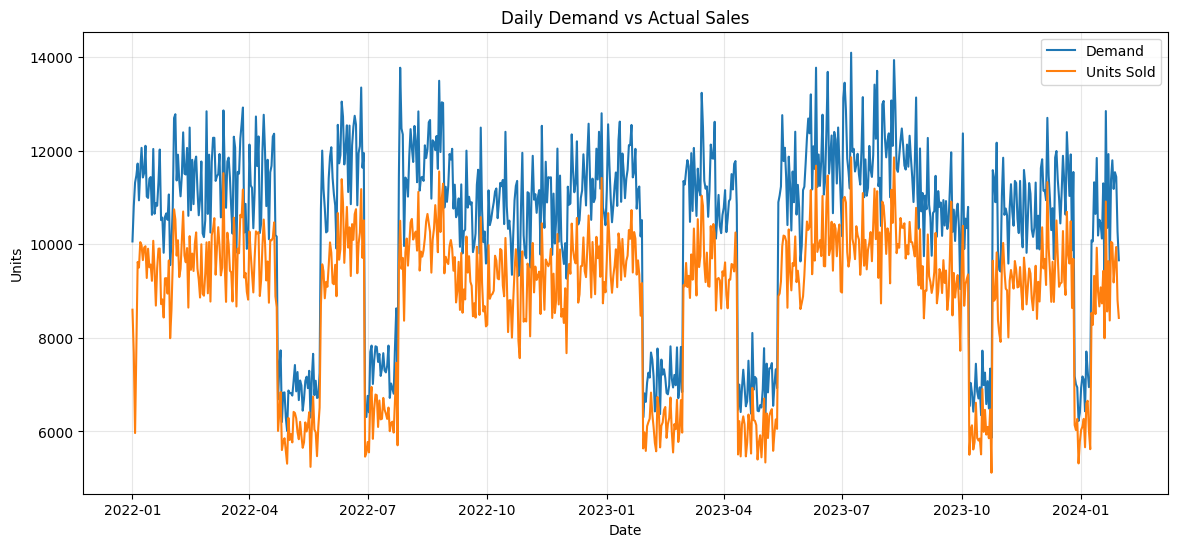

In [24]:
daily = (
    master
    .groupby("date")
    .agg(
        demand=("demand", "sum"),
        sales=("units_sold", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    daily["date"],
    daily["demand"],
    label="Demand"
)

plt.plot(
    daily["date"],
    daily["sales"],
    label="Units Sold"
)

plt.title("Daily Demand vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Units")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [25]:
promotion_analysis = (
    master
    .groupby("promotion")
    .agg(
        avg_demand=("demand", "mean"),
        avg_sales=("units_sold", "mean"),
        avg_discount=("discount", "mean")
    )
)

display(promotion_analysis)

,avg_demand,avg_sales,avg_discount
promotion,,,
0,95.026843,81.833314,4.983333
1,123.269400,103.095080,17.458600


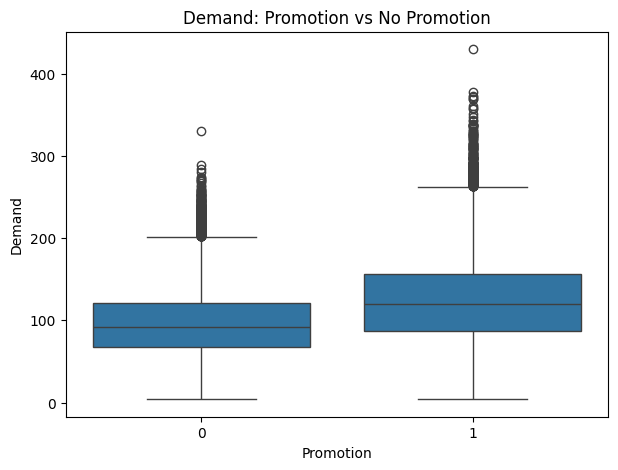

In [26]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=master,
    x="promotion",
    y="demand"
)

plt.title("Demand: Promotion vs No Promotion")
plt.xlabel("Promotion")
plt.ylabel("Demand")

plt.show()

In [27]:
region_analysis = (
    master
    .groupby("region")
    .agg(
        total_demand=("demand", "sum"),
        avg_demand=("demand", "mean"),
        total_sales=("units_sold", "sum"),
        avg_inventory=("inventory_level", "mean")
    )
    .sort_values(
        "total_demand",
        ascending=False
    )
)

display(region_analysis)

,total_demand,avg_demand,total_sales,avg_inventory
region,,,,
North,3154658,103.771645,2680946,279.031118
South,1625471,106.938882,1386126,332.014737
East,1618324,106.468684,1375613,321.993026
West,1529651,100.634934,1308191,293.244211


In [28]:
weather_analysis = (
    master
    .groupby("weather_condition")
    .agg(
        avg_demand=("demand", "mean"),
        avg_sales=("units_sold", "mean")
    )
    .sort_values(
        "avg_demand",
        ascending=False
    )
)

display(weather_analysis)

,avg_demand,avg_sales
weather_condition,,
Sunny,115.167189,97.027937
Cloudy,105.404064,89.625369
Rainy,95.106743,81.972286
Snowy,94.045789,80.948477


In [29]:
season_analysis = (
    master
    .groupby("seasonality")
    .agg(
        avg_demand=("demand", "mean"),
        avg_sales=("units_sold", "mean")
    )
)

display(season_analysis)

,avg_demand,avg_sales
seasonality,,
Autumn,103.422967,88.462637
Spring,97.703098,83.463587
Summer,112.855380,95.757880
Winter,103.406190,87.770524


In [30]:
master = pd.read_csv(
    "../data/processed/master_dataset.csv"
)

master["date"] = pd.to_datetime(
    master["date"],
    errors="coerce"
)

print("Master Dataset Shape:", master.shape)

display(master.head())

Master Dataset Shape: (76000, 15)


,date,store_id,product_id,units_sold,demand,price,discount,promotion,competitor_pricing,inventory_level,units_ordered,region,weather_condition,seasonality,epidemic
0,2022-01-01,S001,P0001,102,115,72.72,5,0,85.73,195,252,North,Snowy,Winter,0
1,2022-01-01,S001,P0002,117,229,80.16,15,1,92.02,117,249,North,Snowy,Winter,0
2,2022-01-01,S001,P0003,114,157,62.94,10,1,60.08,247,612,North,Snowy,Winter,0
3,2022-01-01,S001,P0004,45,52,87.63,10,0,85.19,139,102,North,Snowy,Winter,0
4,2022-01-01,S001,P0005,65,59,54.41,0,0,51.63,152,271,North,Snowy,Winter,0


In [31]:
print("Columns:")
print(master.columns.tolist())

print("\nDate Range:")
print(master["date"].min(), "→", master["date"].max())

print("\nUnique Stores:")
print(master["store_id"].nunique())

print("\nUnique Products:")
print(master["product_id"].nunique())

print("\nTotal Rows:")
print(len(master))

Columns:
['date', 'store_id', 'product_id', 'units_sold', 'demand', 'price', 'discount', 'promotion', 'competitor_pricing', 'inventory_level', 'units_ordered', 'region', 'weather_condition', 'seasonality', 'epidemic']

Date Range:
2022-01-01 00:00:00 → 2024-01-30 00:00:00

Unique Stores:
5

Unique Products:
20

Total Rows:
76000


In [32]:
missing = pd.DataFrame({
    "Missing Count": master.isnull().sum(),
    "Missing %": (
        master.isnull().sum()
        / len(master) * 100
    ).round(2)
})

display(
    missing.sort_values(
        "Missing %",
        ascending=False
    )
)

,Missing Count,Missing %
date,0,0.0
store_id,0,0.0
product_id,0,0.0
units_sold,0,0.0
demand,0,0.0
price,0,0.0
discount,0,0.0
promotion,0,0.0
competitor_pricing,0,0.0
inventory_level,0,0.0


In [33]:
duplicate_keys = master.duplicated(
    subset=["date", "store_id", "product_id"]
).sum()

print("Duplicate Date-Store-Product rows:", duplicate_keys)

Duplicate Date-Store-Product rows: 0


In [34]:
print("Shape:", master.shape)

print(
    "Date Range:",
    master["date"].min(),
    "to",
    master["date"].max()
)

print("Unique Stores:", master["store_id"].nunique())
print("Unique Products:", master["product_id"].nunique())

Shape: (76000, 15)
Date Range: 2022-01-01 00:00:00 to 2024-01-30 00:00:00
Unique Stores: 5
Unique Products: 20


In [35]:
master["unmet_demand"] = (
    master["demand"] - master["units_sold"]
).clip(lower=0)

master["demand_sales_gap"] = (
    master["demand"] - master["units_sold"]
)

display(
    master[
        [
            "units_sold",
            "demand",
            "unmet_demand",
            "inventory_level",
            "units_ordered",
            "price",
            "discount",
            "competitor_pricing"
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
units_sold,76000.0,88.827316,43.994525,0.00,58.0000,84.0,114.0000,426.00
demand,76000.0,104.317158,46.964801,4.00,71.0000,100.0,133.0000,430.00
unmet_demand,76000.0,18.268197,23.658948,0.00,0.0000,11.0,27.0000,316.00
inventory_level,76000.0,301.062842,226.510161,0.00,136.0000,227.0,408.0000,2267.00
units_ordered,76000.0,89.090645,162.404627,0.00,0.0000,0.0,121.0000,1616.00
price,76000.0,67.726028,39.377899,4.74,31.9975,64.5,95.8300,228.03
discount,76000.0,9.087039,7.475781,0.00,5.0000,10.0,10.0000,25.00
competitor_pricing,76000.0,69.454029,40.943818,4.29,32.6200,65.7,97.9325,261.22


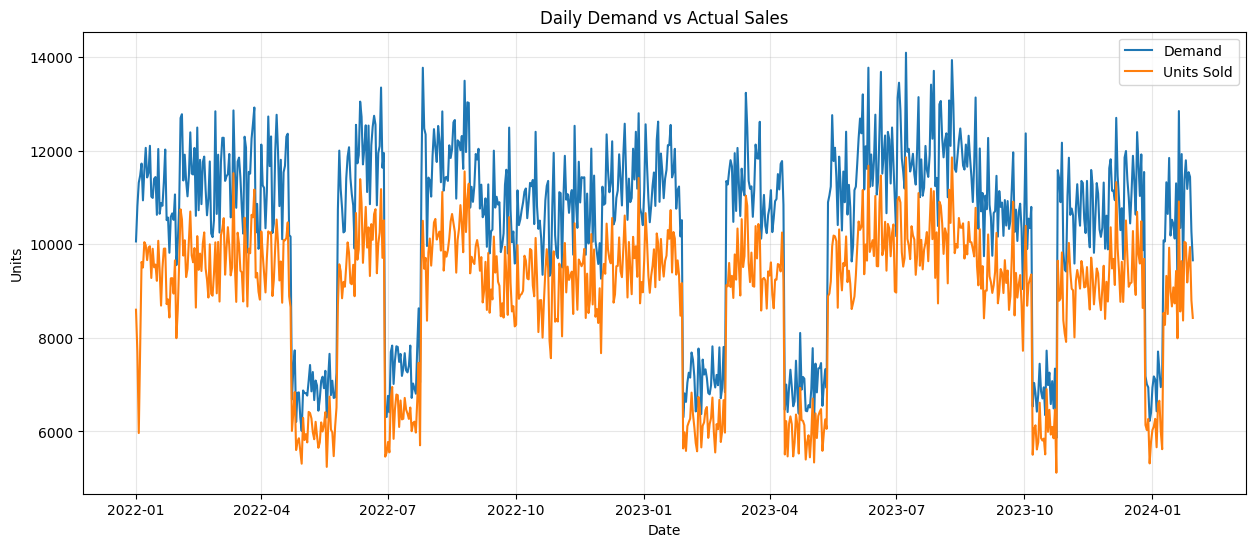

In [36]:
daily = (
    master
    .groupby("date")
    .agg(
        total_demand=("demand", "sum"),
        total_sales=("units_sold", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(15, 6))

plt.plot(
    daily["date"],
    daily["total_demand"],
    label="Demand"
)

plt.plot(
    daily["date"],
    daily["total_sales"],
    label="Units Sold"
)

plt.title("Daily Demand vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Units")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [37]:
total_demand = master["demand"].sum()
total_sales = master["units_sold"].sum()
total_unmet = master["unmet_demand"].sum()

fulfillment_rate = (
    total_sales / total_demand
) * 100

print(f"Total Demand       : {total_demand:,.0f}")
print(f"Total Units Sold   : {total_sales:,.0f}")
print(f"Total Unmet Demand : {total_unmet:,.0f}")
print(f"Fulfillment Rate   : {fulfillment_rate:.2f}%")

Total Demand       : 7,928,104
Total Units Sold   : 6,750,876
Total Unmet Demand : 1,388,383
Fulfillment Rate   : 85.15%


In [38]:
promotion_analysis = (
    master
    .groupby("promotion")
    .agg(
        observations=("demand", "size"),
        avg_demand=("demand", "mean"),
        avg_sales=("units_sold", "mean"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

display(promotion_analysis)

,promotion,observations,avg_demand,avg_sales,avg_discount
0,0,51000,95.026843,81.833314,4.983333
1,1,25000,123.269400,103.095080,17.458600


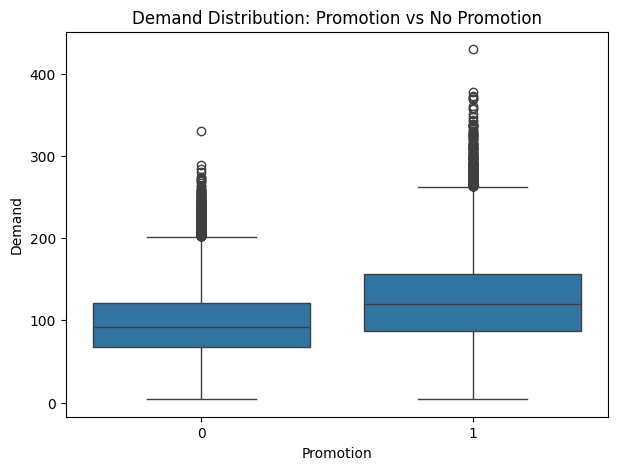

In [39]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=master,
    x="promotion",
    y="demand"
)

plt.title("Demand Distribution: Promotion vs No Promotion")
plt.xlabel("Promotion")
plt.ylabel("Demand")

plt.show()

In [40]:
region_analysis = (
    master
    .groupby("region")
    .agg(
        total_demand=("demand", "sum"),
        avg_demand=("demand", "mean"),
        total_sales=("units_sold", "sum"),
        avg_inventory=("inventory_level", "mean")
    )
    .sort_values(
        "total_demand",
        ascending=False
    )
    .reset_index()
)

display(region_analysis)

,region,total_demand,avg_demand,total_sales,avg_inventory
0,North,3154658,103.771645,2680946,279.031118
1,South,1625471,106.938882,1386126,332.014737
2,East,1618324,106.468684,1375613,321.993026
3,West,1529651,100.634934,1308191,293.244211


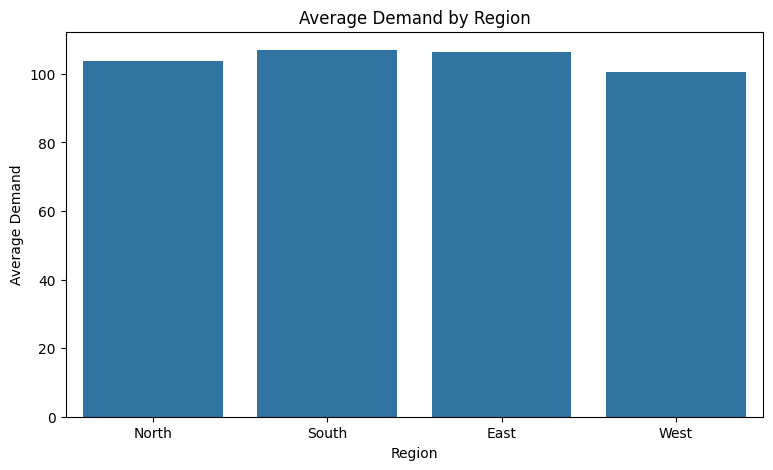

In [41]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=region_analysis,
    x="region",
    y="avg_demand"
)

plt.title("Average Demand by Region")
plt.xlabel("Region")
plt.ylabel("Average Demand")

plt.show()

In [42]:
weather_analysis = (
    master
    .groupby("weather_condition")
    .agg(
        observations=("demand", "size"),
        avg_demand=("demand", "mean"),
        avg_sales=("units_sold", "mean")
    )
    .sort_values(
        "avg_demand",
        ascending=False
    )
    .reset_index()
)

display(weather_analysis)

,weather_condition,observations,avg_demand,avg_sales
0,Sunny,22980,115.167189,97.027937
1,Cloudy,24360,105.404064,89.625369
2,Rainy,17500,95.106743,81.972286
3,Snowy,11160,94.045789,80.948477


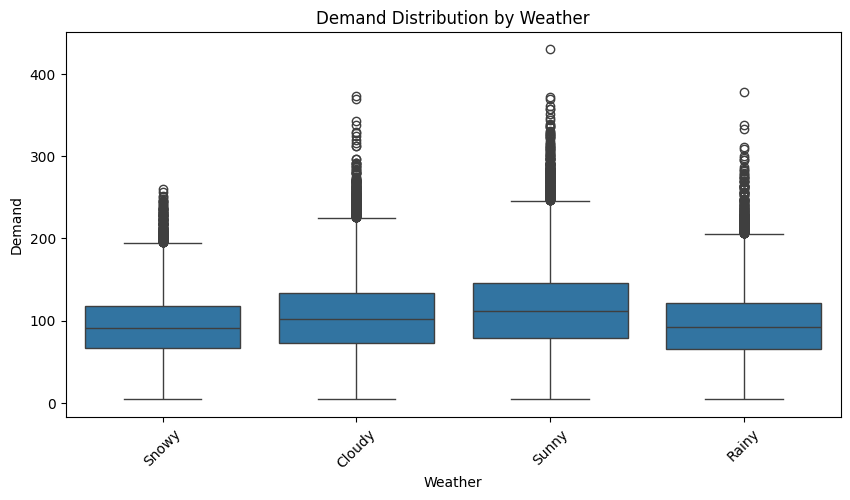

In [43]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=master,
    x="weather_condition",
    y="demand"
)

plt.title("Demand Distribution by Weather")
plt.xlabel("Weather")
plt.ylabel("Demand")
plt.xticks(rotation=45)

plt.show()

In [44]:
season_analysis = (
    master
    .groupby("seasonality")
    .agg(
        avg_demand=("demand", "mean"),
        avg_sales=("units_sold", "mean"),
        avg_inventory=("inventory_level", "mean")
    )
    .reset_index()
)

display(season_analysis)

,seasonality,avg_demand,avg_sales,avg_inventory
0,Autumn,103.422967,88.462637,297.497143
1,Spring,97.703098,83.463587,286.940598
2,Summer,112.855380,95.757880,320.578533
3,Winter,103.406190,87.770524,299.427429


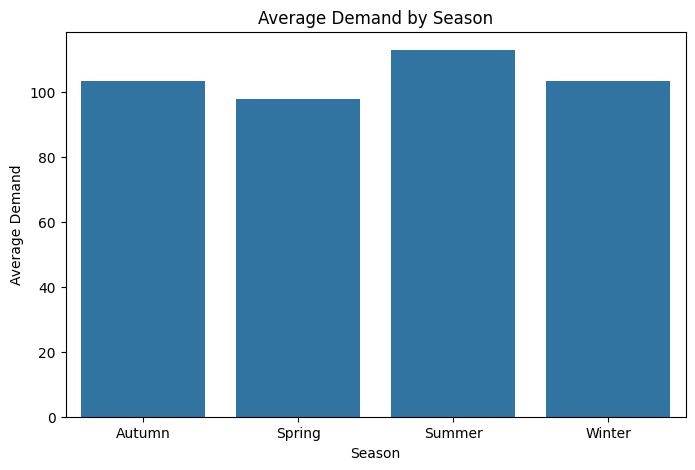

In [45]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=season_analysis,
    x="seasonality",
    y="avg_demand"
)

plt.title("Average Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Demand")

plt.show()

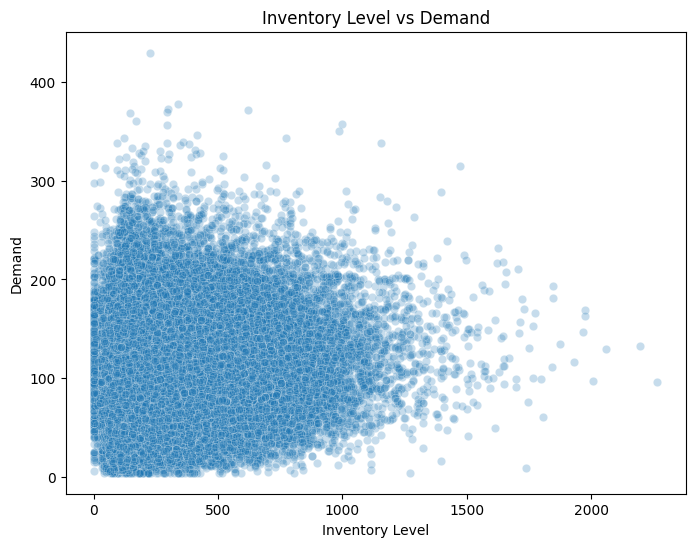

In [46]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=master,
    x="inventory_level",
    y="demand",
    alpha=0.25
)

plt.title("Inventory Level vs Demand")
plt.xlabel("Inventory Level")
plt.ylabel("Demand")

plt.show()

In [47]:
master["inventory_pressure"] = (
    master["demand"] >
    master["inventory_level"]
).astype(int)

pressure_summary = (
    master["inventory_pressure"]
    .value_counts()
    .rename_axis("inventory_pressure")
    .reset_index(name="count")
)

pressure_summary["percentage"] = (
    pressure_summary["count"]
    / len(master) * 100
)

display(pressure_summary)

,inventory_pressure,count,percentage
0,0,65606,86.323684
1,1,10394,13.676316


In [48]:
master["price_difference"] = (
    master["price"]
    - master["competitor_pricing"]
)

display(
    master[
        [
            "price",
            "competitor_pricing",
            "price_difference",
            "demand"
        ]
    ].corr()
)

,price,competitor_pricing,price_difference,demand
price,1.000000,0.976648,-0.069158,-0.023461
competitor_pricing,0.976648,1.000000,-0.281873,-0.023036
price_difference,-0.069158,-0.281873,1.000000,0.002196
demand,-0.023461,-0.023036,0.002196,1.000000


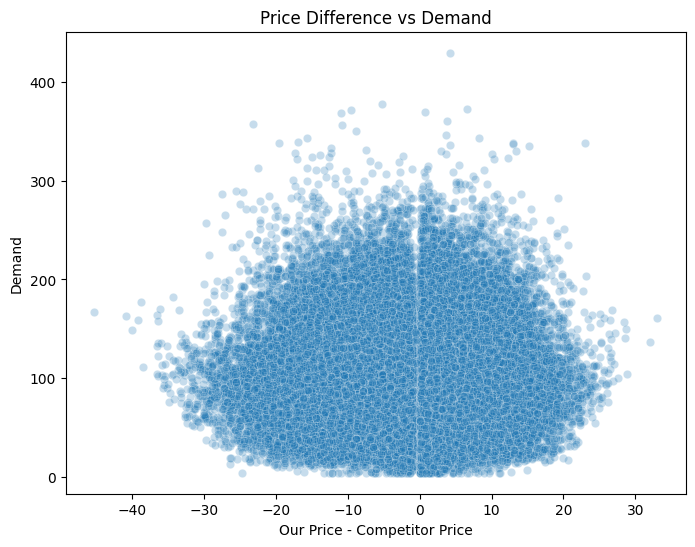

In [49]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=master,
    x="price_difference",
    y="demand",
    alpha=0.25
)

plt.title("Price Difference vs Demand")
plt.xlabel("Our Price - Competitor Price")
plt.ylabel("Demand")

plt.show()

In [50]:
master["year"] = master["date"].dt.year
master["month"] = master["date"].dt.month
master["day_of_week"] = master["date"].dt.dayofweek

master["is_weekend"] = (
    master["day_of_week"] >= 5
).astype(int)

In [51]:
weekday_analysis = (
    master
    .groupby("day_of_week")
    .agg(
        avg_demand=("demand", "mean"),
        avg_sales=("units_sold", "mean")
    )
    .reset_index()
)

display(weekday_analysis)

,day_of_week,avg_demand,avg_sales
0,0,103.423303,87.869450
1,1,103.665229,88.416239
2,2,105.192037,89.552500
3,3,104.408333,88.875648
4,4,104.394444,89.178056
5,5,104.484037,88.956330
6,6,104.662294,88.953303


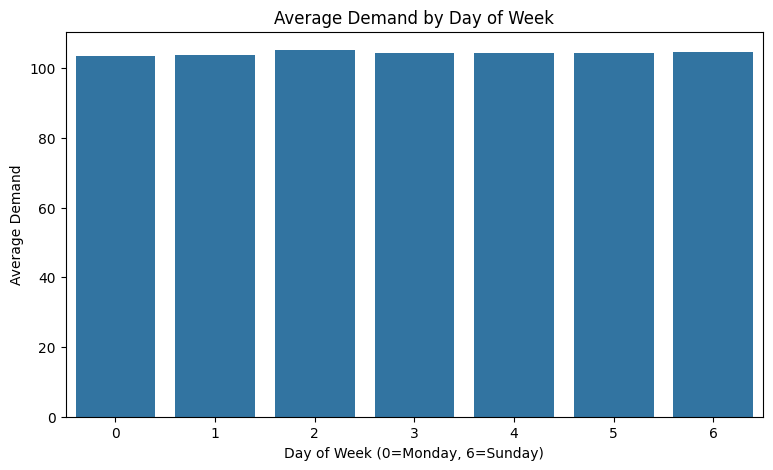

In [52]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=weekday_analysis,
    x="day_of_week",
    y="avg_demand"
)

plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week (0=Monday, 6=Sunday)")
plt.ylabel("Average Demand")

plt.show()

In [53]:
# Create demand gap variables

master["demand_sales_gap"] = (
    master["demand"] - master["units_sold"]
)

master["unmet_demand"] = (
    master["demand_sales_gap"]
    .clip(lower=0)
)

display(
    master[
        [
            "demand",
            "units_sold",
            "demand_sales_gap",
            "unmet_demand"
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
demand,76000.0,104.317158,46.964801,4.0,71.0,100.0,133.0,430.0
units_sold,76000.0,88.827316,43.994525,0.0,58.0,84.0,114.0,426.0
demand_sales_gap,76000.0,15.489842,26.404353,-68.0,-2.0,11.0,27.0,316.0
unmet_demand,76000.0,18.268197,23.658948,0.0,0.0,11.0,27.0,316.0


In [54]:
demand_gap_summary = pd.DataFrame({
    "Condition": [
        "Demand > Sales",
        "Demand = Sales",
        "Demand < Sales"
    ],

    "Count": [
        (master["demand"] > master["units_sold"]).sum(),
        (master["demand"] == master["units_sold"]).sum(),
        (master["demand"] < master["units_sold"]).sum()
    ]
})

demand_gap_summary["Percentage"] = (
    demand_gap_summary["Count"]
    / len(master)
    * 100
).round(2)

display(demand_gap_summary)

,Condition,Count,Percentage
0,Demand > Sales,53440,70.32
1,Demand = Sales,1560,2.05
2,Demand < Sales,21000,27.63


In [55]:
total_demand = master["demand"].sum()
total_sales = master["units_sold"].sum()
total_unmet_demand = master["unmet_demand"].sum()

print(f"Total Demand       : {total_demand:,.0f}")
print(f"Total Units Sold   : {total_sales:,.0f}")
print(f"Total Unmet Demand : {total_unmet_demand:,.0f}")

Total Demand       : 7,928,104
Total Units Sold   : 6,750,876
Total Unmet Demand : 1,388,383


In [56]:
daily_analysis = (
    master
    .groupby("date")
    .agg(
        total_demand=("demand", "sum"),
        total_sales=("units_sold", "sum"),
        total_unmet_demand=("unmet_demand", "sum")
    )
    .reset_index()
)

display(daily_analysis.head())

,date,total_demand,total_sales,total_unmet_demand
0,2022-01-01,10060,8601,1674
1,2022-01-02,10814,7684,3305
2,2022-01-03,11317,5965,5408
3,2022-01-04,11469,7859,3864
4,2022-01-05,11724,9621,2451


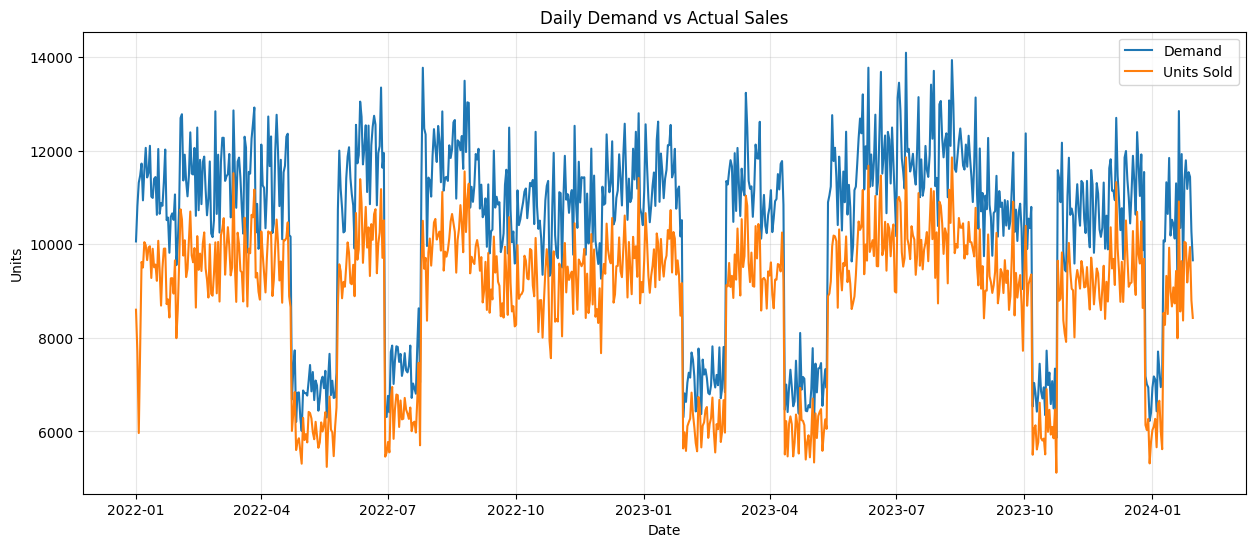

In [57]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_analysis["date"],
    daily_analysis["total_demand"],
    label="Demand"
)

plt.plot(
    daily_analysis["date"],
    daily_analysis["total_sales"],
    label="Units Sold"
)

plt.title("Daily Demand vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Units")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

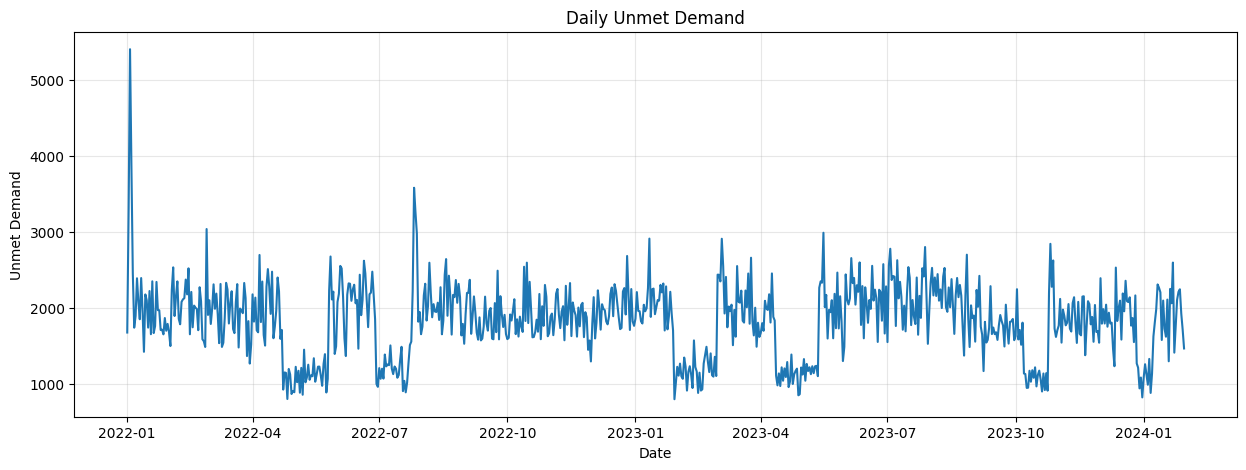

In [58]:
plt.figure(figsize=(15, 5))

plt.plot(
    daily_analysis["date"],
    daily_analysis["total_unmet_demand"]
)

plt.title("Daily Unmet Demand")
plt.xlabel("Date")
plt.ylabel("Unmet Demand")
plt.grid(alpha=0.3)

plt.show()

In [59]:
master["inventory_gap"] = (
    master["inventory_level"]
    - master["demand"]
)

master["inventory_pressure"] = (
    master["demand"]
    > master["inventory_level"]
).astype(int)

In [60]:
inventory_pressure_summary = (
    master["inventory_pressure"]
    .value_counts()
    .rename_axis("inventory_pressure")
    .reset_index(name="count")
)

inventory_pressure_summary["percentage"] = (
    inventory_pressure_summary["count"]
    / len(master)
    * 100
).round(2)

display(inventory_pressure_summary)

,inventory_pressure,count,percentage
0,0,65606,86.32
1,1,10394,13.68


In [61]:
display(
    master
    .groupby("inventory_pressure")
    .agg(
        observations=("demand", "size"),
        avg_demand=("demand", "mean"),
        avg_sales=("units_sold", "mean"),
        avg_inventory=("inventory_level", "mean"),
        avg_unmet_demand=("unmet_demand", "mean")
    )
)

,observations,avg_demand,avg_sales,avg_inventory,avg_unmet_demand
inventory_pressure,,,,,
0,65606,98.454638,88.500594,333.625507,13.172576
1,10394,141.320858,90.889552,95.530210,50.431307


In [62]:
promotion_analysis = (
    master
    .groupby("promotion")
    .agg(
        observations=("demand", "size"),
        avg_demand=("demand", "mean"),
        avg_sales=("units_sold", "mean"),
        avg_discount=("discount", "mean"),
        avg_unmet_demand=("unmet_demand", "mean")
    )
    .reset_index()
)

display(promotion_analysis)

,promotion,observations,avg_demand,avg_sales,avg_discount,avg_unmet_demand
0,0,51000,95.026843,81.833314,4.983333,15.814196
1,1,25000,123.269400,103.095080,17.458600,23.274360


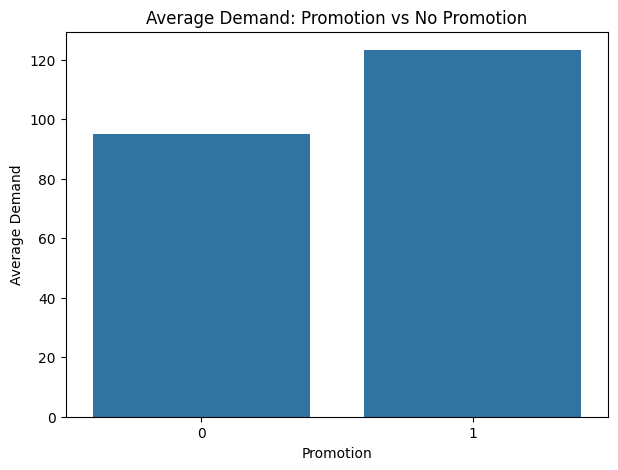

In [63]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=promotion_analysis,
    x="promotion",
    y="avg_demand"
)

plt.title("Average Demand: Promotion vs No Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Demand")

plt.show()

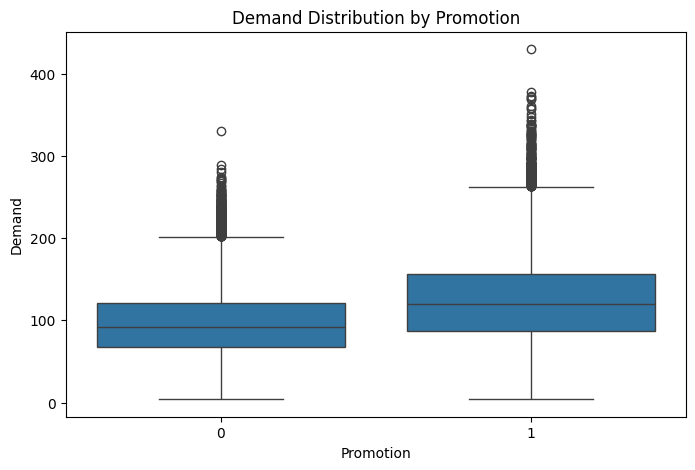

In [64]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=master,
    x="promotion",
    y="demand"
)

plt.title("Demand Distribution by Promotion")
plt.xlabel("Promotion")
plt.ylabel("Demand")

plt.show()

In [65]:
discount_analysis = (
    master
    .groupby("discount")
    .agg(
        observations=("demand", "size"),
        avg_demand=("demand", "mean"),
        avg_sales=("units_sold", "mean")
    )
    .reset_index()
    .sort_values("discount")
)

display(discount_analysis)

,discount,observations,avg_demand,avg_sales
0,0,17126,94.748861,81.574156
1,5,16918,94.941896,81.694763
2,10,23298,102.767834,87.657953
3,15,6245,123.575981,102.878463
4,20,6191,124.065256,103.774834
5,25,6222,122.967374,103.587914


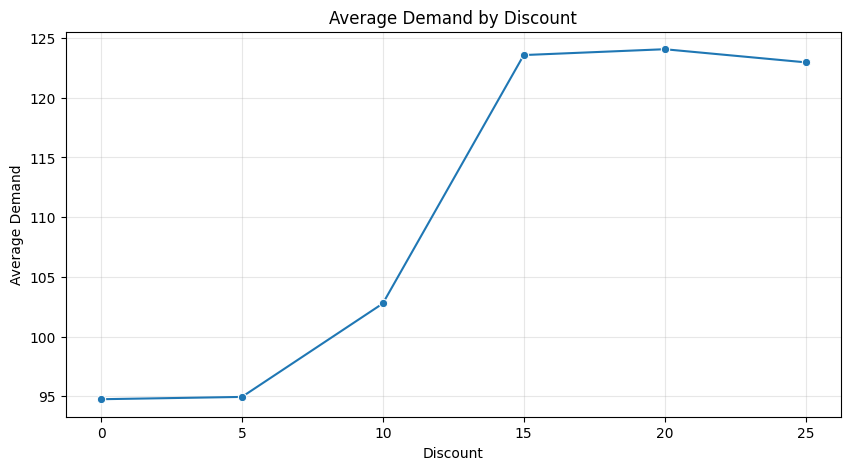

In [66]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=discount_analysis,
    x="discount",
    y="avg_demand",
    marker="o"
)

plt.title("Average Demand by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Demand")

plt.grid(alpha=0.3)
plt.show()

In [67]:
print(
    "Discount-Demand Correlation:",
    round(
        master["discount"].corr(
            master["demand"]
        ),
        4
    )
)

Discount-Demand Correlation: 0.2247


In [68]:
display(
    master[
        [
            "price",
            "competitor_pricing",
            "price_difference",
            "demand"
        ]
    ].corr()
)

,price,competitor_pricing,price_difference,demand
price,1.000000,0.976648,-0.069158,-0.023461
competitor_pricing,0.976648,1.000000,-0.281873,-0.023036
price_difference,-0.069158,-0.281873,1.000000,0.002196
demand,-0.023461,-0.023036,0.002196,1.000000


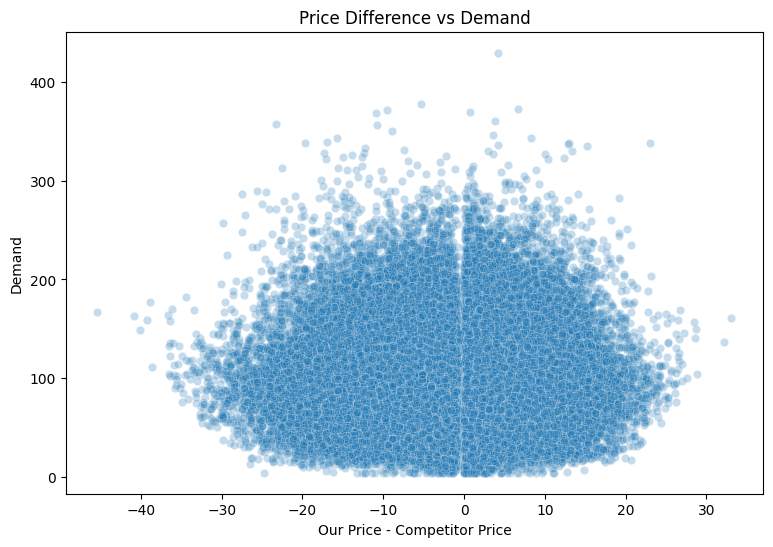

In [69]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=master,
    x="price_difference",
    y="demand",
    alpha=0.25
)

plt.title("Price Difference vs Demand")
plt.xlabel("Our Price - Competitor Price")
plt.ylabel("Demand")

plt.show()

In [70]:
region_analysis = (
    master
    .groupby("region")
    .agg(
        observations=("demand", "size"),
        total_demand=("demand", "sum"),
        avg_demand=("demand", "mean"),
        total_sales=("units_sold", "sum"),
        avg_inventory=("inventory_level", "mean"),
        avg_unmet_demand=("unmet_demand", "mean")
    )
    .reset_index()
    .sort_values(
        "avg_demand",
        ascending=False
    )
)

display(region_analysis)

,region,observations,total_demand,avg_demand,total_sales,avg_inventory,avg_unmet_demand
2,South,15200,1625471,106.938882,1386126,332.014737,18.676908
0,East,15200,1618324,106.468684,1375613,321.993026,18.714803
1,North,30400,3154658,103.771645,2680946,279.031118,18.301053
3,West,15200,1529651,100.634934,1308191,293.244211,17.347171


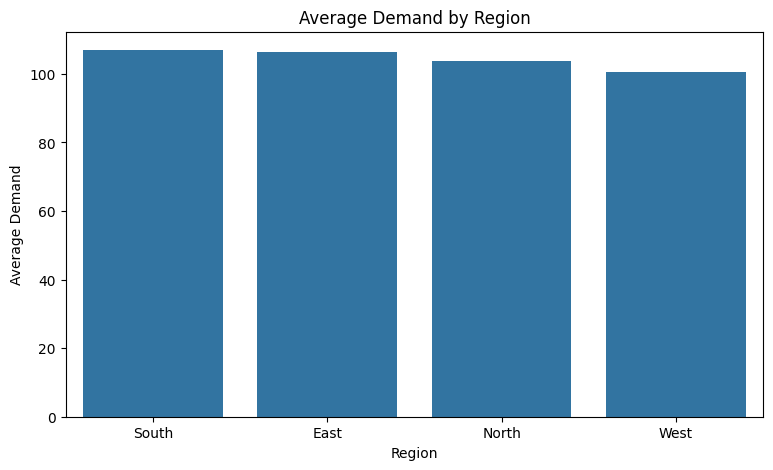

In [71]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=region_analysis,
    x="region",
    y="avg_demand"
)

plt.title("Average Demand by Region")
plt.xlabel("Region")
plt.ylabel("Average Demand")

plt.show()

In [72]:
weather_analysis = (
    master
    .groupby("weather_condition")
    .agg(
        observations=("demand", "size"),
        avg_demand=("demand", "mean"),
        avg_sales=("units_sold", "mean"),
        avg_unmet_demand=("unmet_demand", "mean")
    )
    .reset_index()
    .sort_values(
        "avg_demand",
        ascending=False
    )
)

display(weather_analysis)

,weather_condition,observations,avg_demand,avg_sales,avg_unmet_demand
3,Sunny,22980,115.167189,97.027937,21.091950
0,Cloudy,24360,105.404064,89.625369,18.553120
1,Rainy,17500,95.106743,81.972286,15.799771
2,Snowy,11160,94.045789,80.948477,15.702509


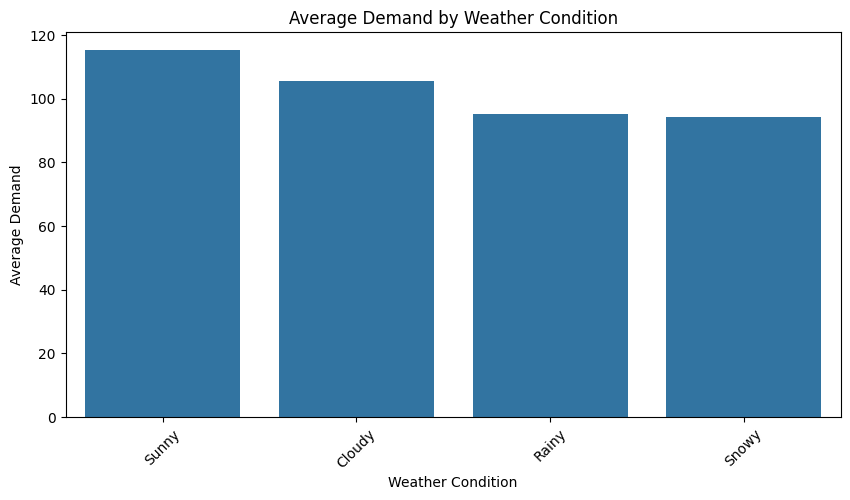

In [73]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=weather_analysis,
    x="weather_condition",
    y="avg_demand"
)

plt.title("Average Demand by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Demand")

plt.xticks(rotation=45)
plt.show()

In [74]:
season_analysis = (
    master
    .groupby("seasonality")
    .agg(
        observations=("demand", "size"),
        avg_demand=("demand", "mean"),
        avg_sales=("units_sold", "mean"),
        avg_inventory=("inventory_level", "mean")
    )
    .reset_index()
)

display(season_analysis)

,seasonality,observations,avg_demand,avg_sales,avg_inventory
0,Autumn,18200,103.422967,88.462637,297.497143
1,Spring,18400,97.703098,83.463587,286.940598
2,Summer,18400,112.855380,95.757880,320.578533
3,Winter,21000,103.406190,87.770524,299.427429


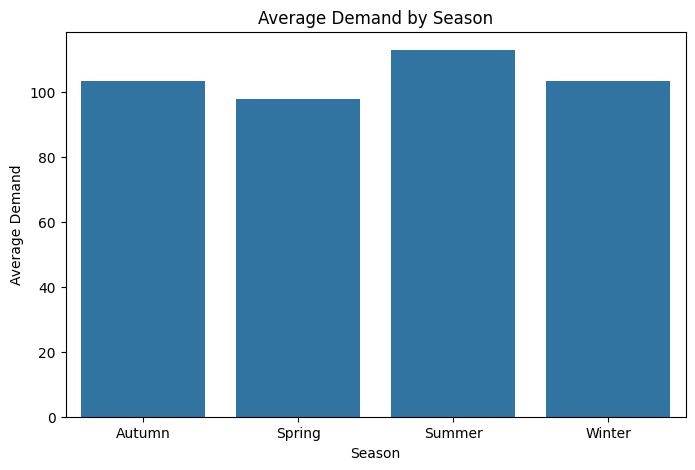

In [75]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=season_analysis,
    x="seasonality",
    y="avg_demand"
)

plt.title("Average Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Demand")

plt.show()

In [76]:
epidemic_analysis = (
    master
    .groupby("epidemic")
    .agg(
        observations=("demand", "size"),
        avg_demand=("demand", "mean"),
        avg_sales=("units_sold", "mean"),
        avg_inventory=("inventory_level", "mean"),
        avg_unmet_demand=("unmet_demand", "mean")
    )
    .reset_index()
)

display(epidemic_analysis)

,epidemic,observations,avg_demand,avg_sales,avg_inventory,avg_unmet_demand
0,0,60800,112.856743,95.819211,312.110773,20.010576
1,1,15200,70.158816,60.859737,256.871118,11.298684


In [77]:
master["day_of_week"] = master["date"].dt.dayofweek

master["is_weekend"] = (
    master["day_of_week"] >= 5
).astype(int)

In [78]:
day_analysis = (
    master
    .groupby("day_of_week")
    .agg(
        avg_demand=("demand", "mean"),
        avg_sales=("units_sold", "mean")
    )
    .reset_index()
)

display(day_analysis)

,day_of_week,avg_demand,avg_sales
0,0,103.423303,87.869450
1,1,103.665229,88.416239
2,2,105.192037,89.552500
3,3,104.408333,88.875648
4,4,104.394444,89.178056
5,5,104.484037,88.956330
6,6,104.662294,88.953303


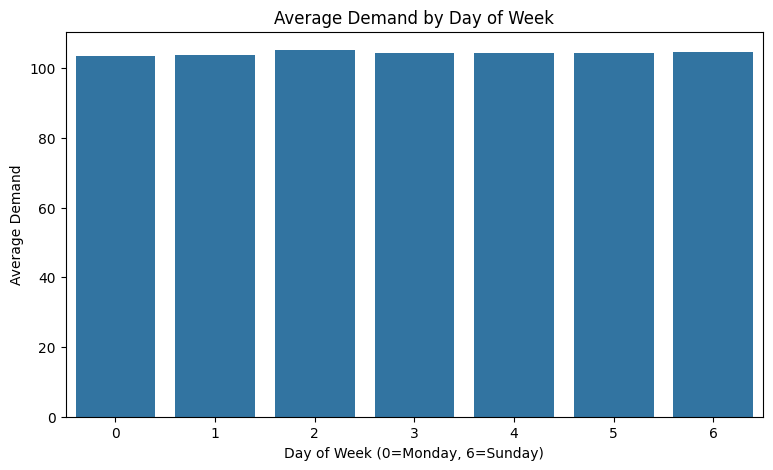

In [79]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=day_analysis,
    x="day_of_week",
    y="avg_demand"
)

plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week (0=Monday, 6=Sunday)")
plt.ylabel("Average Demand")

plt.show()

In [80]:
weekend_analysis = (
    master
    .groupby("is_weekend")
    .agg(
        observations=("demand", "size"),
        avg_demand=("demand", "mean"),
        avg_sales=("units_sold", "mean")
    )
    .reset_index()
)

display(weekend_analysis)

,is_weekend,observations,avg_demand,avg_sales
0,0,54200,104.214188,88.776033
1,1,21800,104.573165,88.954817


In [81]:
# ============================================================
# 8. STATISTICAL ANALYSIS
# STOCKSENSE - Round 1
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

ALPHA = 0.05

print("=" * 70)
print("STOCKSENSE - STATISTICAL ANALYSIS")
print("=" * 70)
print(f"Significance Level (Alpha): {ALPHA}")


# ============================================================
# TEST 1: PROMOTION VS DEMAND
# Welch Independent T-Test
# ============================================================

print("\n" + "=" * 70)
print("TEST 1: PROMOTION VS DEMAND")
print("=" * 70)

promotion_demand = master.loc[
    master["promotion"] == 1,
    "demand"
].dropna()

non_promotion_demand = master.loc[
    master["promotion"] == 0,
    "demand"
].dropna()

print("H0: Mean demand is equal for promotion and non-promotion periods.")
print("H1: Mean demand differs between promotion and non-promotion periods.")

print("\nPromotion observations:", len(promotion_demand))
print("Non-promotion observations:", len(non_promotion_demand))

print(
    "Promotion Mean Demand:",
    round(promotion_demand.mean(), 2)
)

print(
    "Non-Promotion Mean Demand:",
    round(non_promotion_demand.mean(), 2)
)

t_stat_promo, p_value_promo = stats.ttest_ind(
    promotion_demand,
    non_promotion_demand,
    equal_var=False
)

print("\nT-Statistic:", round(t_stat_promo, 4))
print("P-Value:", p_value_promo)

if p_value_promo < ALPHA:
    promo_result = "Significant"
    print(
        "Result: Reject H0. "
        "There is statistically significant evidence of a "
        "difference in mean demand between promotion and "
        "non-promotion periods."
    )
else:
    promo_result = "Not Significant"
    print(
        "Result: Fail to reject H0. "
        "There is insufficient evidence of a difference "
        "in mean demand."
    )


# ============================================================
# TEST 2: WEATHER CONDITION VS DEMAND
# One-Way ANOVA
# ============================================================

print("\n" + "=" * 70)
print("TEST 2: WEATHER CONDITION VS DEMAND")
print("=" * 70)

weather_groups = [
    group["demand"].dropna().values
    for _, group in master.groupby("weather_condition")
]

weather_names = (
    master["weather_condition"]
    .dropna()
    .unique()
)

print("H0: Mean demand is equal across weather conditions.")
print("H1: At least one weather condition has different mean demand.")

print("\nWeather Conditions:")
print(weather_names)

print("\nNumber of Weather Groups:", len(weather_groups))

f_stat_weather, p_value_weather = stats.f_oneway(
    *weather_groups
)

print("\nF-Statistic:", round(f_stat_weather, 4))
print("P-Value:", p_value_weather)

if p_value_weather < ALPHA:
    weather_result = "Significant"
    print(
        "Result: Reject H0. "
        "There is statistically significant evidence that "
        "mean demand differs across at least some weather conditions."
    )
else:
    weather_result = "Not Significant"
    print(
        "Result: Fail to reject H0. "
        "There is insufficient evidence that mean demand "
        "differs across weather conditions."
    )


# ============================================================
# TEST 3: DISCOUNT VS DEMAND
# Pearson Correlation
# ============================================================

print("\n" + "=" * 70)
print("TEST 3: DISCOUNT VS DEMAND")
print("=" * 70)

discount_data = master[
    ["discount", "demand"]
].dropna()

corr_discount, p_value_discount = stats.pearsonr(
    discount_data["discount"],
    discount_data["demand"]
)

print("H0: No linear association exists between discount and demand.")
print("H1: A linear association exists between discount and demand.")

print(
    "\nPearson Correlation:",
    round(corr_discount, 4)
)

print(
    "P-Value:",
    p_value_discount
)

if p_value_discount < ALPHA:
    discount_result = "Significant"

    print(
        "Result: Reject H0. "
        "There is statistically significant evidence of "
        "a linear association between discount and demand."
    )

else:
    discount_result = "Not Significant"

    print(
        "Result: Fail to reject H0. "
        "There is insufficient evidence of a linear "
        "association between discount and demand."
    )


# ============================================================
# TEST 4: PRICE DIFFERENCE VS DEMAND
# Pearson Correlation
# ============================================================

print("\n" + "=" * 70)
print("TEST 4: PRICE DIFFERENCE VS DEMAND")
print("=" * 70)

# Create price_difference if it does not already exist

if "price_difference" not in master.columns:

    master["price_difference"] = (
        master["price"]
        - master["competitor_pricing"]
    )


price_data = master[
    ["price_difference", "demand"]
].dropna()


corr_price, p_value_price = stats.pearsonr(
    price_data["price_difference"],
    price_data["demand"]
)


print(
    "H0: No linear association exists between "
    "relative price and demand."
)

print(
    "H1: A linear association exists between "
    "relative price and demand."
)


print(
    "\nPearson Correlation:",
    round(corr_price, 4)
)

print(
    "P-Value:",
    p_value_price
)


if p_value_price < ALPHA:

    price_result = "Significant"

    print(
        "Result: Reject H0. "
        "There is statistically significant evidence of "
        "a linear association between relative price and demand."
    )

else:

    price_result = "Not Significant"

    print(
        "Result: Fail to reject H0. "
        "There is insufficient evidence of a linear "
        "association between relative price and demand."
    )


# ============================================================
# TEST 5: WEEKEND VS WEEKDAY DEMAND
# Welch Independent T-Test
# ============================================================

print("\n" + "=" * 70)
print("TEST 5: WEEKEND VS WEEKDAY DEMAND")
print("=" * 70)


# Create calendar features if they don't exist

if "day_of_week" not in master.columns:

    master["day_of_week"] = (
        master["date"].dt.dayofweek
    )


if "is_weekend" not in master.columns:

    master["is_weekend"] = (
        master["day_of_week"] >= 5
    ).astype(int)


weekend_demand = master.loc[
    master["is_weekend"] == 1,
    "demand"
].dropna()


weekday_demand = master.loc[
    master["is_weekend"] == 0,
    "demand"
].dropna()


print("H0: Mean weekend demand equals mean weekday demand.")
print("H1: Mean weekend demand differs from mean weekday demand.")


print(
    "\nWeekend Observations:",
    len(weekend_demand)
)

print(
    "Weekday Observations:",
    len(weekday_demand)
)


print(
    "Weekend Mean Demand:",
    round(weekend_demand.mean(), 2)
)

print(
    "Weekday Mean Demand:",
    round(weekday_demand.mean(), 2)
)


t_stat_weekend, p_value_weekend = stats.ttest_ind(
    weekend_demand,
    weekday_demand,
    equal_var=False
)


print(
    "\nT-Statistic:",
    round(t_stat_weekend, 4)
)

print(
    "P-Value:",
    p_value_weekend
)


if p_value_weekend < ALPHA:

    weekend_result = "Significant"

    print(
        "Result: Reject H0. "
        "There is statistically significant evidence "
        "of a difference between weekend and weekday demand."
    )

else:

    weekend_result = "Not Significant"

    print(
        "Result: Fail to reject H0. "
        "There is insufficient evidence of a difference "
        "between weekend and weekday demand."
    )


# ============================================================
# CREATE FINAL STATISTICAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("STATISTICAL ANALYSIS SUMMARY")
print("=" * 70)


statistical_results = pd.DataFrame({

    "Analysis": [
        "Promotion vs Demand",
        "Weather vs Demand",
        "Discount vs Demand",
        "Price Difference vs Demand",
        "Weekend vs Weekday Demand"
    ],

    "Test": [
        "Welch T-Test",
        "One-Way ANOVA",
        "Pearson Correlation",
        "Pearson Correlation",
        "Welch T-Test"
    ],

    "Statistic": [
        t_stat_promo,
        f_stat_weather,
        corr_discount,
        corr_price,
        t_stat_weekend
    ],

    "P_Value": [
        p_value_promo,
        p_value_weather,
        p_value_discount,
        p_value_price,
        p_value_weekend
    ],

    "Result": [
        promo_result,
        weather_result,
        discount_result,
        price_result,
        weekend_result
    ]
})


statistical_results["Statistic"] = (
    statistical_results["Statistic"]
    .round(4)
)


display(statistical_results)


# ============================================================
# SAVE RESULTS
# ============================================================

output_path = "../reports/statistical_analysis.csv"

statistical_results.to_csv(
    output_path,
    index=False
)


print("\n" + "=" * 70)

print(
    "Statistical analysis saved successfully:"
)

print(output_path)

print("=" * 70)

STOCKSENSE - STATISTICAL ANALYSIS
Significance Level (Alpha): 0.05

TEST 1: PROMOTION VS DEMAND
H0: Mean demand is equal for promotion and non-promotion periods.
H1: Mean demand differs between promotion and non-promotion periods.

Promotion observations: 25000
Non-promotion observations: 51000
Promotion Mean Demand: 123.27
Non-Promotion Mean Demand: 95.03

T-Statistic: 74.3362
P-Value: 0.0
Result: Reject H0. There is statistically significant evidence of a difference in mean demand between promotion and non-promotion periods.

TEST 2: WEATHER CONDITION VS DEMAND
H0: Mean demand is equal across weather conditions.
H1: At least one weather condition has different mean demand.

Weather Conditions:
['Snowy' 'Cloudy' 'Sunny' 'Rainy']

Number of Weather Groups: 4

F-Statistic: 842.5558
P-Value: 0.0
Result: Reject H0. There is statistically significant evidence that mean demand differs across at least some weather conditions.

TEST 3: DISCOUNT VS DEMAND
H0: No linear association exists betwe

,Analysis,Test,Statistic,P_Value,Result
0,Promotion vs Demand,Welch T-Test,74.3362,0.000000,Significant
1,Weather vs Demand,One-Way ANOVA,842.5558,0.000000,Significant
2,Discount vs Demand,Pearson Correlation,0.2247,0.000000,Significant
3,Price Difference vs Demand,Pearson Correlation,0.0022,0.544953,Not Significant
4,Weekend vs Weekday Demand,Welch T-Test,0.9496,0.342302,Not Significant



Statistical analysis saved successfully:
../reports/statistical_analysis.csv
